In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ball_by_ball = pd.read_csv('/kaggle/input/ipl-ball-by-ball-dataset-2008-2025/ball_by_ball_ipl_data.csv')
match_info = pd.read_csv('/kaggle/input/ipl-ball-by-ball-dataset-2008-2025/basic_info.csv')

print(f" Ball-by-ball: {ball_by_ball.shape[0]:,} rows × {ball_by_ball.shape[1]} columns")
print(f" Match info: {match_info.shape[0]:,} rows × {match_info.shape[1]} columns")
print("\nFirst 5 rows:")
ball_by_ball.head()


 Ball-by-ball: 278,205 rows × 10 columns
 Match info: 1,169 rows × 9 columns

First 5 rows:


,Unnamed: 0,id,batter_name,bowler_name,non_striker_name,batsman_run,extra_run,total_run,batting_team,bowling_team
0,0,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
1,1,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
2,2,0,DA Warner,TS Mills,S Dhawan,4,0,4,Sunrisers Hyderabad,Royal Challengers Bangalore
3,3,0,DA Warner,TS Mills,S Dhawan,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
4,4,0,DA Warner,TS Mills,S Dhawan,0,2,2,Sunrisers Hyderabad,Royal Challengers Bangalore


In [3]:
missing_summary = pd.DataFrame({
    'column': ball_by_ball.columns,
    'missing_count': ball_by_ball.isnull().sum().values,
    'missing_percentage': (ball_by_ball.isnull().sum().values / len(ball_by_ball) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

print("Missing Values:")
print(missing_summary)


Missing Values:
         column  missing_count  missing_percentage
9  bowling_team            495                0.18


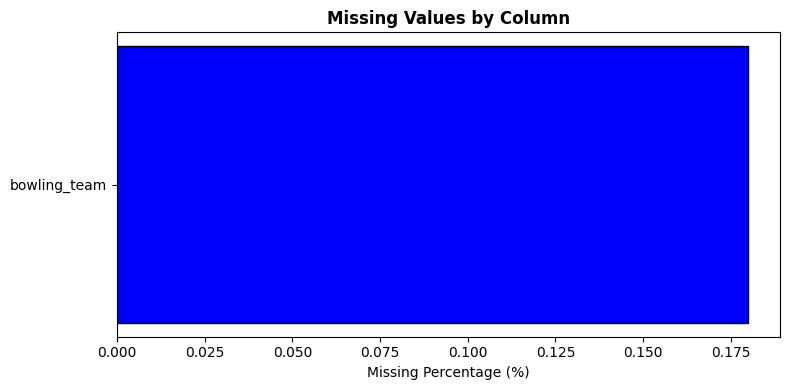

In [4]:
if len(missing_summary) > 0:
    plt.figure(figsize=(8, 4))
    plt.barh(missing_summary['column'], missing_summary['missing_percentage'], color='blue', edgecolor='black')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [5]:
duplicate_count = ball_by_ball.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    ball_by_ball.drop_duplicates(inplace=True)
    print(f" Removed {duplicate_count} duplicates")


Duplicate rows: 0


In [6]:
def get_bowling_team_from_bowler(bowler_name, df):
    bowler_team = df[
        (df['bowler_name'] == bowler_name) & 
        (df['bowling_team'].notna())
    ]['bowling_team'].mode()
    
    return bowler_team.values[0] if len(bowler_team) > 0 else None


In [7]:
missing_bowling = ball_by_ball[ball_by_ball['bowling_team'].isnull()]

if len(missing_bowling) > 0:
    matches_with_missing = missing_bowling['id'].unique()
    print(f"Found {len(missing_bowling)} missing values in {len(matches_with_missing)} matches\n")
    
    for match_id in matches_with_missing:
        bowler = ball_by_ball[ball_by_ball['id'] == match_id]['bowler_name'].iloc[0]
        team = get_bowling_team_from_bowler(bowler, ball_by_ball)
        
        if team:
            ball_by_ball.loc[ball_by_ball['id'] == match_id, 'bowling_team'] = team
            print(f" Match {match_id}: {team}")
    
    print(f"\nFinal missing count: {ball_by_ball['bowling_team'].isnull().sum()}")


Found 495 missing values in 5 matches

 Match 417: Chennai Super Kings
 Match 572: Kolkata Knight Riders
 Match 575: Royal Challengers Bangalore
 Match 833: Pune Warriors
 Match 1078: Mumbai Indians

Final missing count: 0


In [8]:
print(f"Teams before: {ball_by_ball['batting_team'].nunique()}")

team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}

ball_by_ball['batting_team'] = ball_by_ball['batting_team'].replace(team_mapping)
ball_by_ball['bowling_team'] = ball_by_ball['bowling_team'].replace(team_mapping)

print(f"Teams after: {ball_by_ball['batting_team'].nunique()}")
print("\nFinal teams:", sorted(ball_by_ball['batting_team'].unique()))


Teams before: 19
Teams after: 15

Final teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [9]:
print("MATCH STATISTICS")

total_matches = ball_by_ball['id'].nunique()
total_balls = len(ball_by_ball)

print(f"Total Matches: {total_matches:,}")
print(f"Total Balls: {total_balls:,}")
print(f"Average Balls per Match: {total_balls / total_matches:.2f}")


MATCH STATISTICS
Total Matches: 1,169
Total Balls: 278,205
Average Balls per Match: 237.99


In [10]:
print("TEAM STATISTICS")
print(f"Total Teams: {ball_by_ball['batting_team'].nunique()}")
print("\nMatches played by each team:")
team_matches = ball_by_ball.groupby('batting_team')['id'].nunique().sort_values(ascending=False)
for team, matches in team_matches.items():
    print(f"  • {team}: {matches} matches")


TEAM STATISTICS
Total Teams: 15

Matches played by each team:
  • Mumbai Indians: 277 matches
  • Royal Challengers Bengaluru: 270 matches
  • Delhi Capitals: 266 matches
  • Kolkata Knight Riders: 264 matches
  • Punjab Kings: 264 matches
  • Chennai Super Kings: 251 matches
  • Rajasthan Royals: 234 matches
  • Sunrisers Hyderabad: 195 matches
  • Deccan Chargers: 75 matches
  • Gujarat Titans: 60 matches
  • Lucknow Super Giants: 58 matches
  • Pune Warriors: 45 matches
  • Gujarat Lions: 30 matches
  • Rising Pune Supergiants: 30 matches
  • Kochi Tuskers Kerala: 14 matches


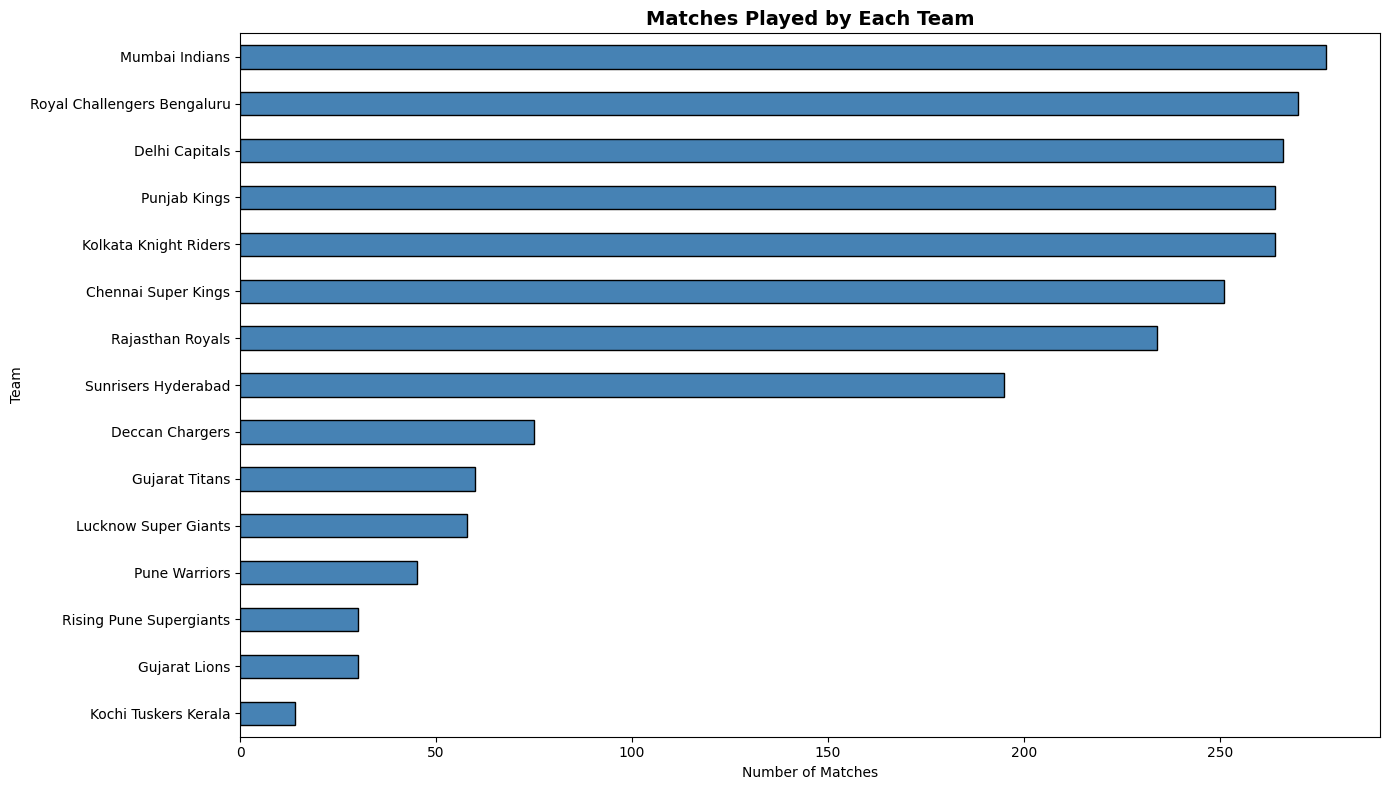

In [11]:
plt.figure(figsize=(14, 8))
team_matches.sort_values(ascending=True).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Matches Played by Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [12]:
print("PLAYER STATISTICS")
print(f"Total Batters: {ball_by_ball['batter_name'].nunique():,}")
print(f"Total Bowlers: {ball_by_ball['bowler_name'].nunique():,}")
print("\nTop 10 Batters (Most Balls Faced):")
for i, (player, count) in enumerate(ball_by_ball['batter_name'].value_counts().head(10).items(), 1):
    print(f"  {i}. {player}: {count:,} balls")
print("\nTop 10 Bowlers (Most Balls Bowled):")
for i, (player, count) in enumerate(ball_by_ball['bowler_name'].value_counts().head(10).items(), 1):
    print(f"  {i}. {player}: {count:,} balls")


PLAYER STATISTICS
Total Batters: 703
Total Bowlers: 550

Top 10 Batters (Most Balls Faced):
  1. V Kohli: 6,702 balls
  2. S Dhawan: 5,483 balls
  3. RG Sharma: 5,475 balls
  4. DA Warner: 4,849 balls
  5. SK Raina: 4,177 balls
  6. AM Rahane: 4,133 balls
  7. MS Dhoni: 4,101 balls
  8. KL Rahul: 3,947 balls
  9. RV Uthappa: 3,927 balls
  10. KD Karthik: 3,687 balls

Top 10 Bowlers (Most Balls Bowled):
  1. R Ashwin: 4,868 balls
  2. SP Narine: 4,421 balls
  3. B Kumar: 4,378 balls
  4. RA Jadeja: 4,127 balls
  5. YS Chahal: 3,905 balls
  6. PP Chawla: 3,895 balls
  7. Harbhajan Singh: 3,496 balls
  8. JJ Bumrah: 3,474 balls
  9. A Mishra: 3,444 balls
  10. AR Patel: 3,371 balls


In [13]:
print("RUNS ANALYSIS")
total_runs = ball_by_ball['batsman_run'].sum()
print(f"Total Runs Scored: {total_runs:,}")
print(f"Strike Rate: {(total_runs / total_balls * 100):.2f}")
print(f"Run Rate (per over): {(total_runs / total_balls * 6):.2f}")
print("\nRun Distribution:")
for run in sorted(ball_by_ball['batsman_run'].unique()):
    count = len(ball_by_ball[ball_by_ball['batsman_run'] == run])
    pct = count / total_balls * 100
    print(f"  {run} runs: {count:,} balls ({pct:.2f}%)")


RUNS ANALYSIS
Total Runs Scored: 355,373
Strike Rate: 127.74
Run Rate (per over): 7.66

Run Distribution:
  0 runs: 110,250 balls (39.63%)
  1 runs: 103,187 balls (37.09%)
  2 runs: 17,424 balls (6.26%)
  3 runs: 811 balls (0.29%)
  4 runs: 32,113 balls (11.54%)
  5 runs: 67 balls (0.02%)
  6 runs: 14,353 balls (5.16%)


In [14]:
print("DATA QUALITY REPORT - FINAL")
quality_report = {
    'Total Records': f"{len(ball_by_ball):,}",
    'Total Columns': ball_by_ball.shape[1],
    'Total Matches': f"{total_matches:,}",
    'Unique Teams': ball_by_ball['batting_team'].nunique(),
    'Unique Batters': f"{ball_by_ball['batter_name'].nunique():,}",
    'Unique Bowlers': f"{ball_by_ball['bowler_name'].nunique():,}",
    'Total Runs': f"{total_runs:,}",
    'Missing Values': ball_by_ball.isnull().sum().sum(),
}
for key, value in quality_report.items():
    print(f"{key:.<40} {value}")


DATA QUALITY REPORT - FINAL
Total Records........................... 278,205
Total Columns........................... 10
Total Matches........................... 1,169
Unique Teams............................ 15
Unique Batters.......................... 703
Unique Bowlers.......................... 550
Total Runs.............................. 355,373
Missing Values.......................... 0
